In [1]:
import os
import sys
current_dir = os.path.dirname(os.getcwd())
if not current_dir in sys.path:
    sys.path.append(current_dir)

# ----------------------------------------------------

In [2]:
import math
import torch
import numpy as np
import phantom as pt
import IR_UTE as ute
import torchkbnufft as tkbn
import randialSampling as rs
import matplotlib.pyplot as plt


# create phantom
img_size = 256
inner_size = 80
mixed_size = 160
upper_square_size = 20
outer_size = 190

# values in seconds
t1_wm = 0.8       
t2_wm = 0.08
t1_myelin = 0.226         
t2_myelin = 300 * 1e-6

# Time Step
dt = 10 # unite: us

# Off-resonance frequencies
df = np.linspace(-500, 500, 200)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## 1. Create Virtual Phantom

### (1) Myelin (T1 map, T2 map, Probability map)

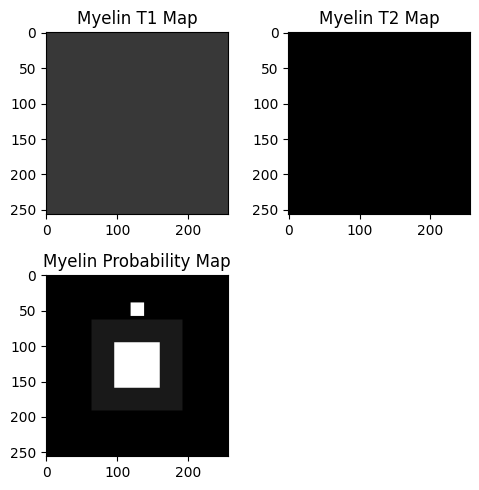

In [3]:
inner_myelin = 1
mixed_myelin = 0.1
outer_myelin = 0

myelin = pt.VirtualPhantom(img_size)
t1_map_myelin, t2_map_myelin, prob_map_myelin = myelin.create_maps(t1_myelin, t2_myelin, inner_myelin, mixed_myelin, outer_myelin, upper_sqaure=True)
myelin.phantom_display('Myelin')

### (2) White Matter (T1 map, T2 map, Probability map)

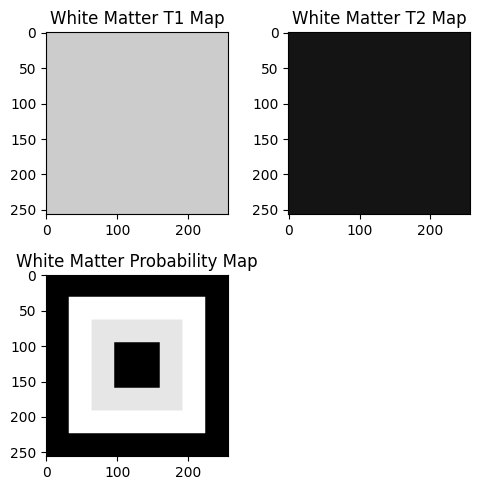

In [4]:
inner_wm = 0
mixed_wm = 0.9
outer_wm = 1

wm = pt.VirtualPhantom(img_size)
t1_map_wm, t2_map_wm, prob_map_wm = wm.create_maps(t1_wm, t2_wm, inner_wm, mixed_wm, outer_wm, upper_sqaure = True)
wm.phantom_display('White Matter')

## 2. IR-UTE Simulation

In [5]:
n_readout = 30
t_readout = 0.768 * 1e-3
t_nullout = int(0.55066 * 1e6)
flip_angle = torch.pi/18*2

### (1） White Matter IR-UTE

In [6]:
wm = ute.IR_UTE(dt, df, t1_wm, t2_wm)
m_ir = wm.inversion_recovery()

### ----------- calculate TI ---------------
#t_nullout = wm.calculate_nulling_point()
#print(t_nullout)
### ----------------------------------------

full_mag_series_wm, excitation_time_wm, mag_readout_start_wm, t_mag_readout_start_wm = wm.transverse_excitation(n_readout, t_readout, t_nullout, flip_angle)

t_readout_end_index: 201
write_start: 0
initial_mag: [-7.06986687e-06  1.57819874e-05  1.00375896e-06]
Angle=0.3490658503988659, M after 1 step: [-7.07147428e-06  1.57865557e-05  1.34947159e-05]
write_start: 201
initial_mag: [0.        0.        0.0024896]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 1.41923172e-06 2.50206468e-03]
write_start: 402
initial_mag: [0.         0.         0.00482264]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 2.74257135e-06 4.83507436e-03]
write_start: 603
initial_mag: [0.         0.         0.00700474]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 3.98029561e-06 7.01714661e-03]
write_start: 804
initial_mag: [0.         0.         0.00904566]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 5.13794352e-06 9.05804655e-03]
write_start: 1005
initial_mag: [0.         0.         0.01095455]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 6.22069572e-06 1.09669075e-02]
write_start: 1206
initial_mag: [0.   

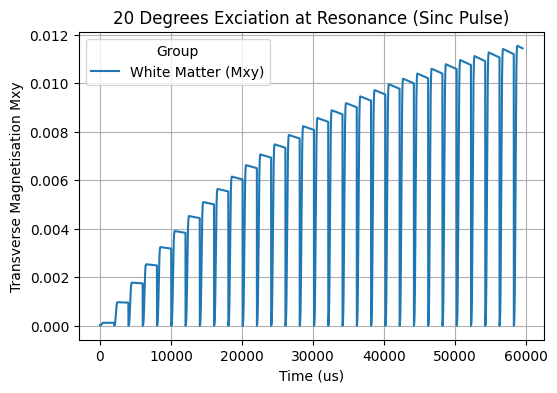

In [7]:
title = 'White Matter (Mxy)'
wm.magnetization_display_xy(full_mag_series_wm, title)

### (2) Myelin IR-UTE

In [8]:
myelin = ute.IR_UTE(dt, df, t1_myelin, t2_myelin)
m_ir = myelin.inversion_recovery()

full_mag_series_myelin, excitation_time_myelin, mag_readout_start_myelin, t_mag_readout_start_myelin = myelin.transverse_excitation(n_readout, t_readout, t_nullout, flip_angle)


t_readout_end_index: 201
write_start: 0
initial_mag: [-7.41098469e-323 -7.41098469e-323  9.06131383e-001]
Angle=0.3490658503988659, M after 1 step: [-7.41098469e-323  5.15936666e-004  9.06135389e-001]
write_start: 201
initial_mag: [0.         0.         0.86510508]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 4.92578089e-04 8.65110909e-01]
write_start: 402
initial_mag: [0.         0.         0.82633531]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 4.70504279e-04 8.26342855e-01]
write_start: 603
initial_mag: [0.         0.         0.78969794]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 4.49644572e-04 7.89707121e-01]
write_start: 804
initial_mag: [0.         0.         0.75507571]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 4.29932189e-04 7.55086423e-01]
write_start: 1005
initial_mag: [0.         0.         0.72235776]
Angle=0.3490658503988659, M after 1 step: [0.00000000e+00 4.11304027e-04 7.22369932e-01]
write_start: 1206
initial_ma

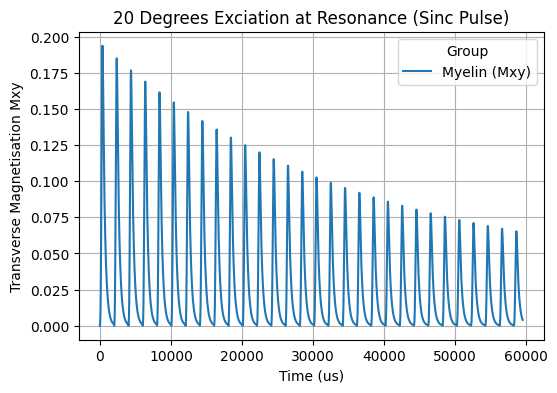

In [9]:
title = 'Myelin (Mxy)'
myelin.magnetization_display_xy(full_mag_series_myelin, title)

## 3. Radial Sampling

### (1) Visual numbers of readouts within single inversion time

#### a. Myelin

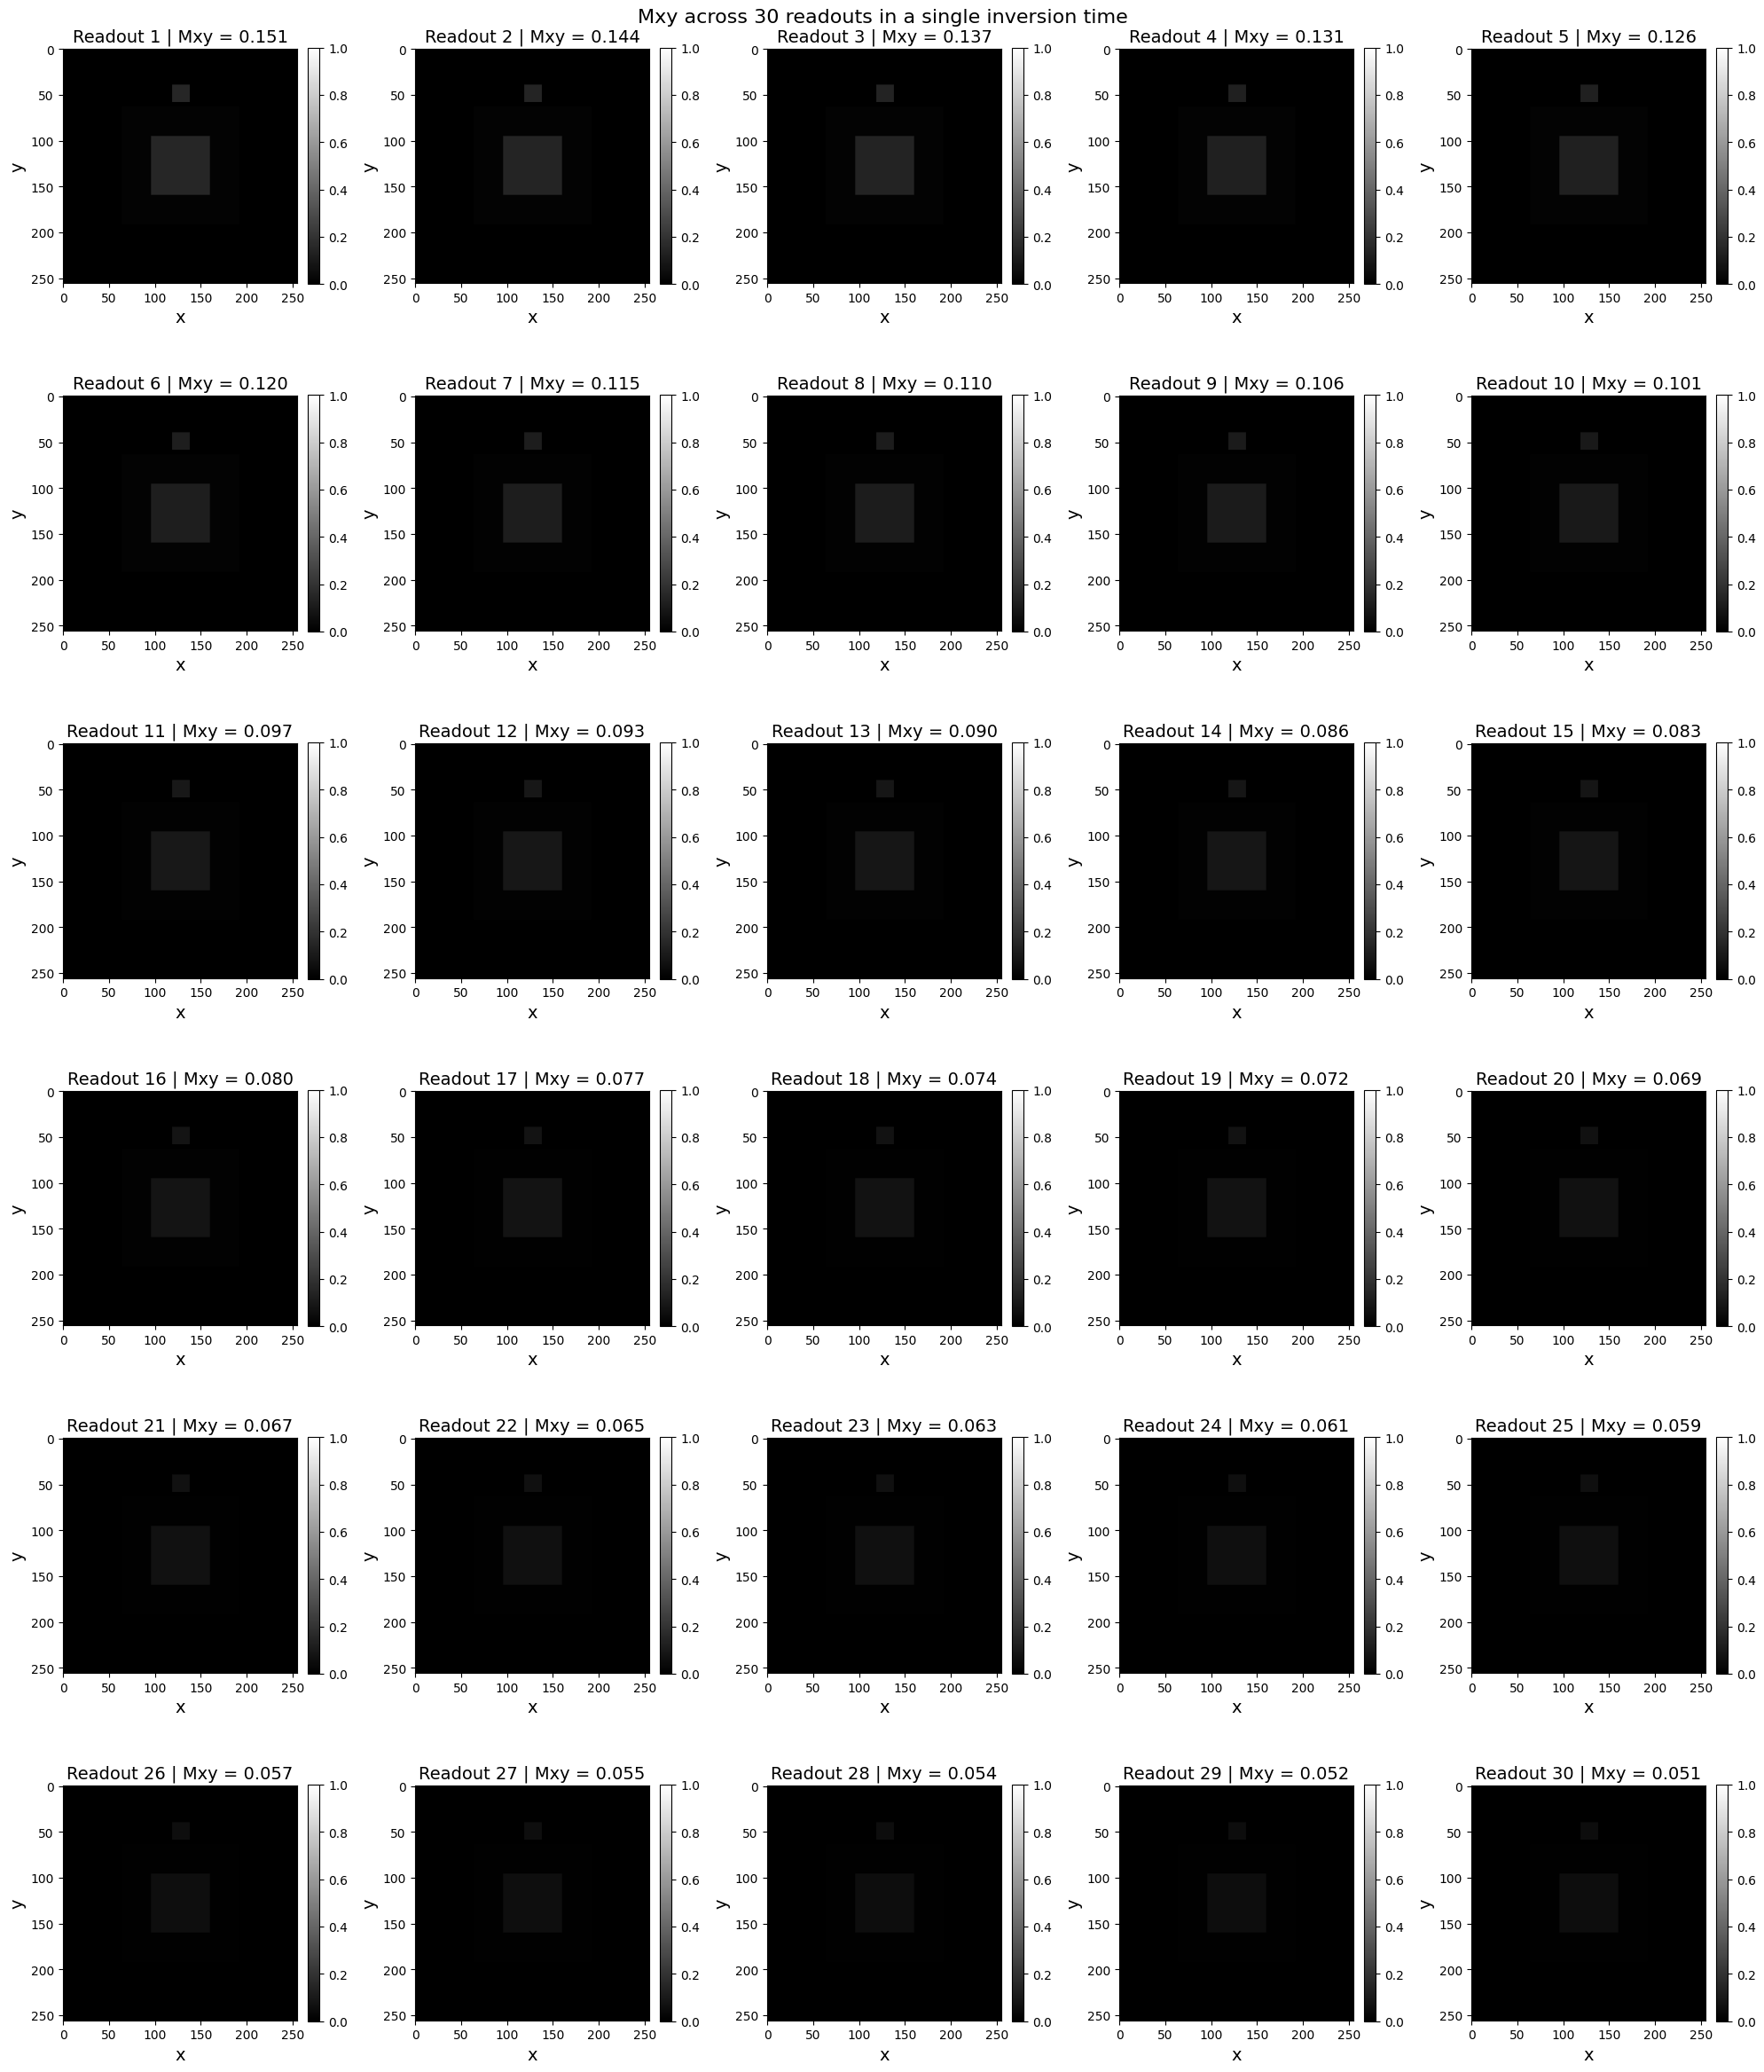

In [10]:
radial_sampling = rs.RadialSampling(img_size)
radial_sampling.visualReadoutsInSingleTI(mag_readout_start_myelin, df, prob_map_myelin)

#### b. White Matter

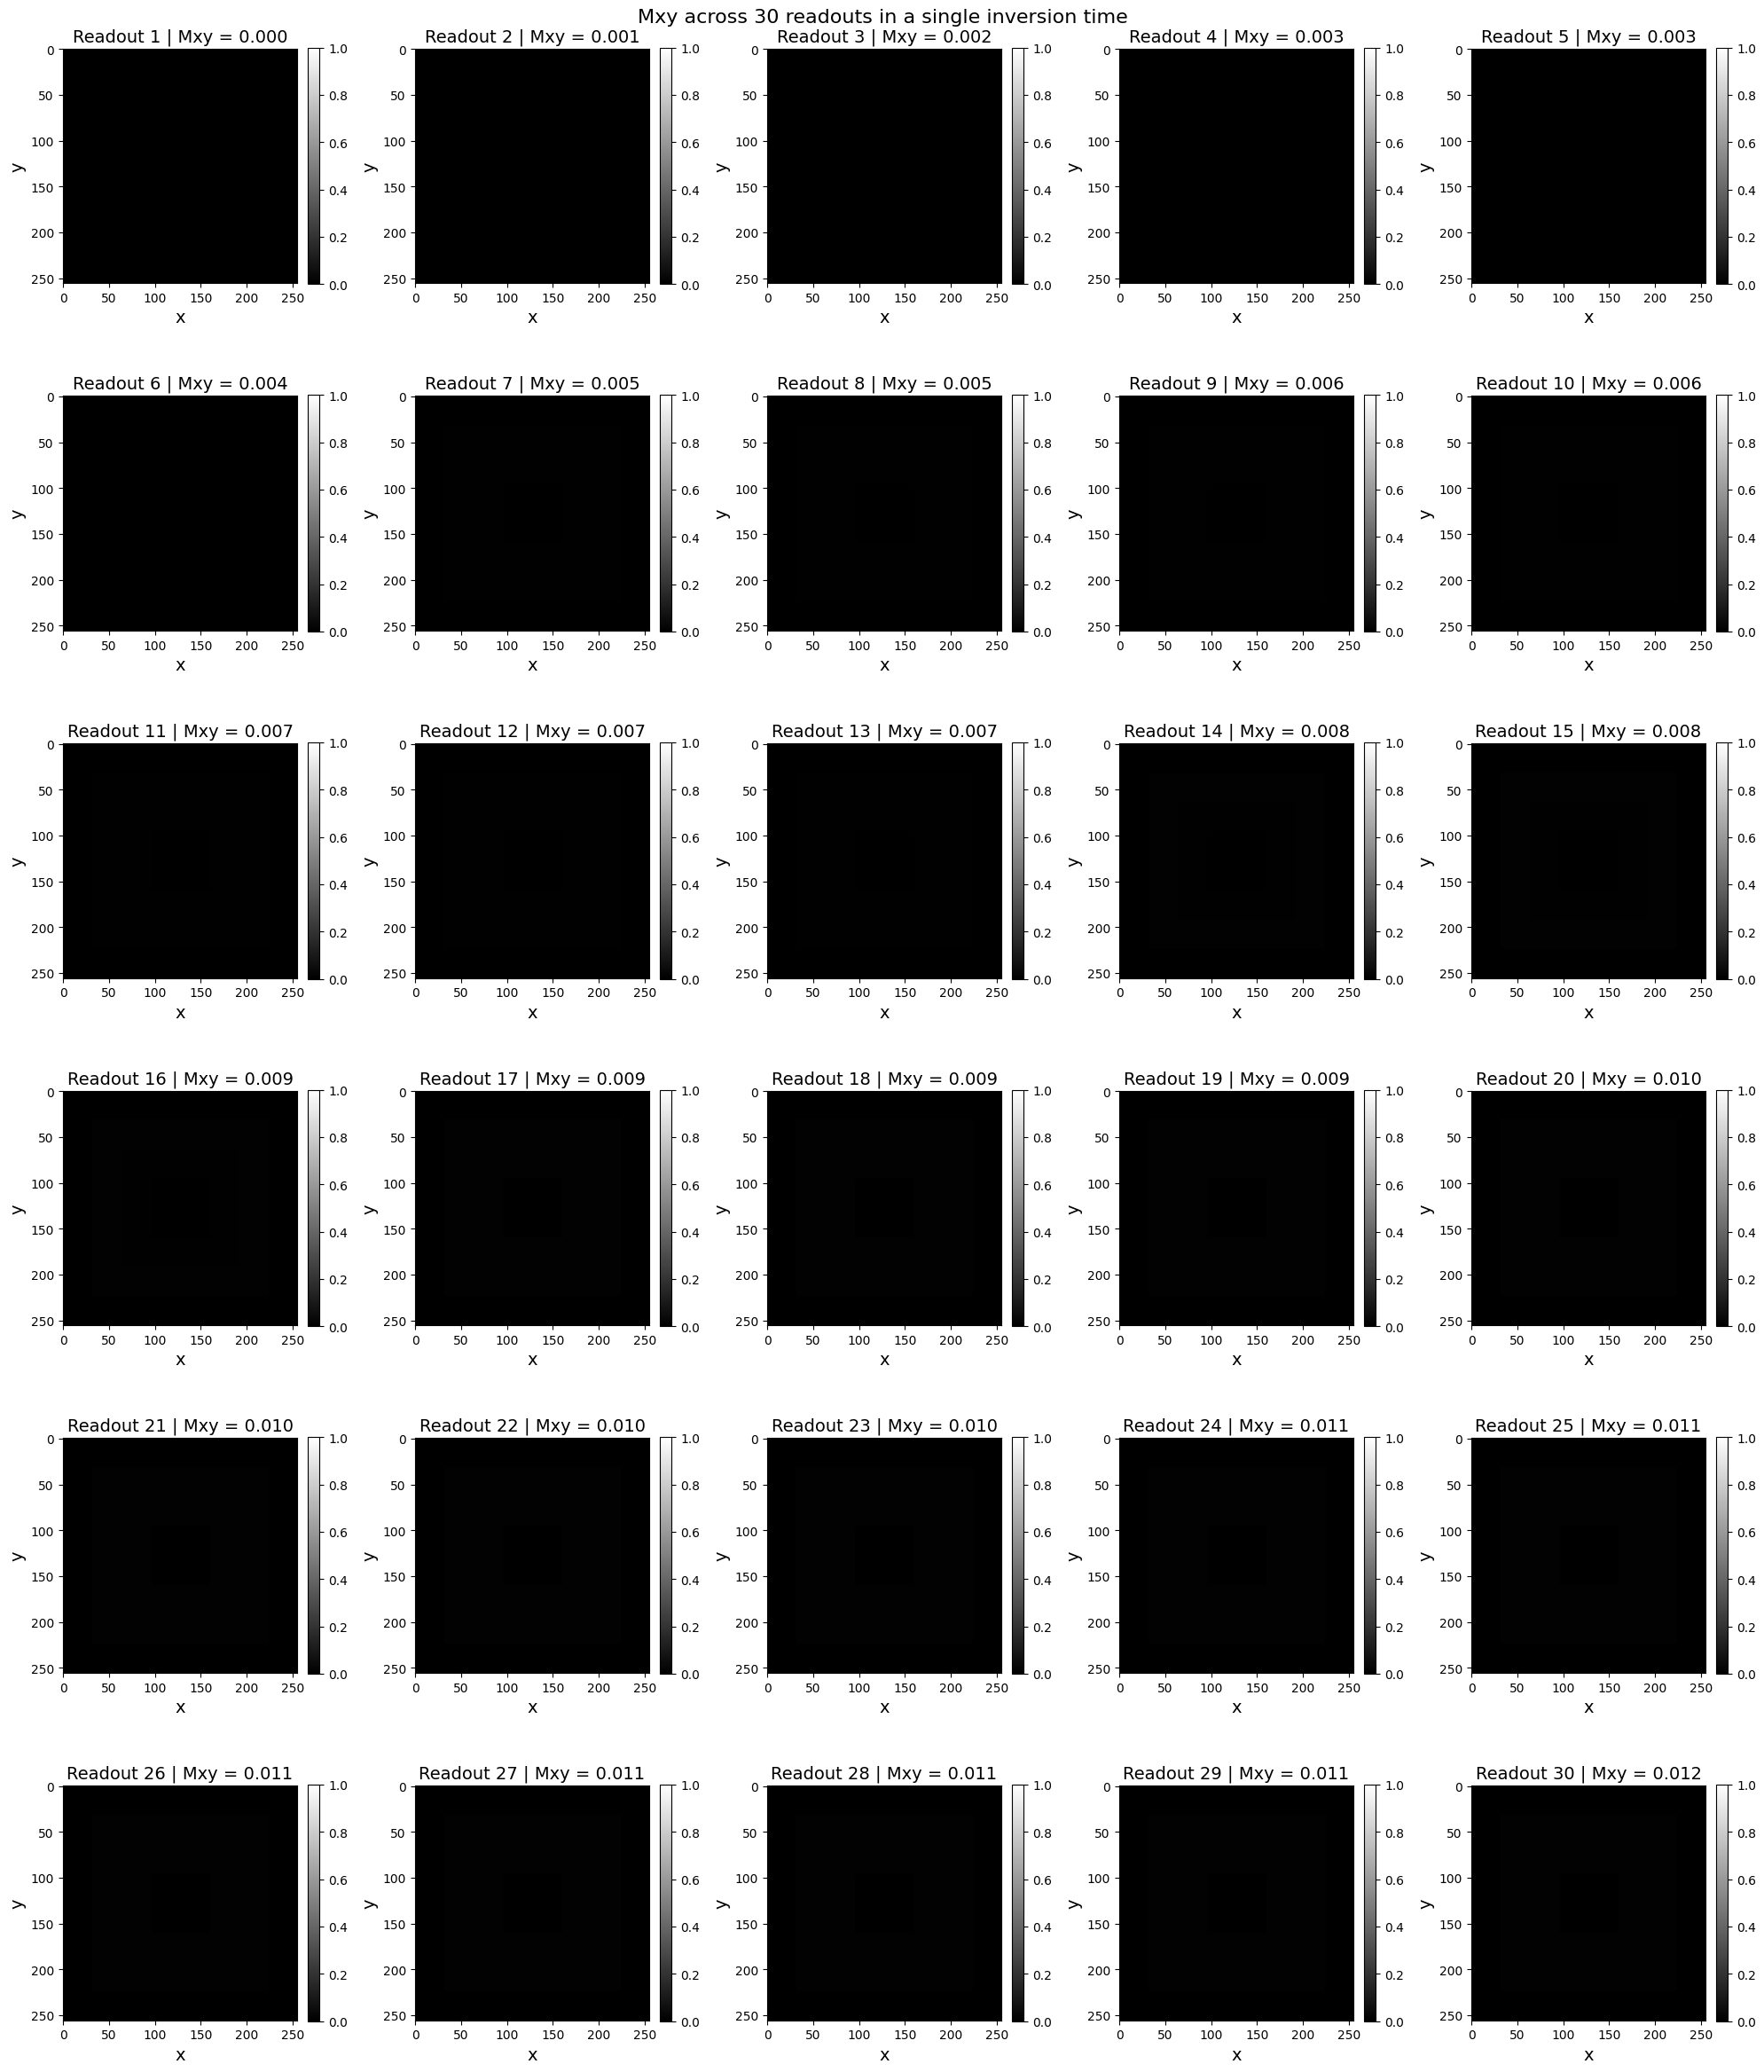

In [11]:
radial_sampling.visualReadoutsInSingleTI(mag_readout_start_wm, df, prob_map_wm)

### (2) Get kspace data and kspace trajectory
n numbers of readouts have been taken withing one inversion time, and only one spoke has been acquired from a single readout 

#### a. Myelin

In [12]:
kdata_t_myelin, ktraj_total = radial_sampling.get_kdata_ktraj(df, mag_readout_start_myelin, prob_map_myelin, n_readout, t2_myelin, t_readout)

#### b. White Matter

In [13]:
kdata_t_wm, ktraj_total = radial_sampling.get_kdata_ktraj(df, mag_readout_start_wm, prob_map_wm, n_readout, t2_wm, t_readout)

### (3) Log10 Kdata (without noise)

#### a. Myelin

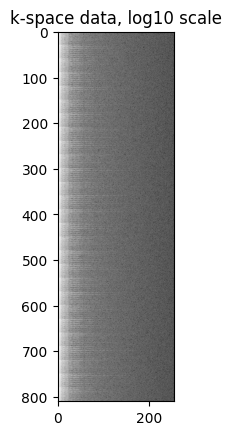

In [14]:
radial_sampling.visual_logKdata(kdata_t_myelin, t2_myelin, t_readout)

#### b. White Matter

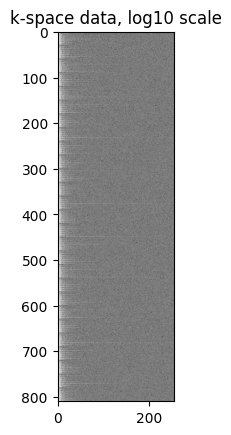

In [15]:
radial_sampling.visual_logKdata(kdata_t_wm, t2_wm, t_readout)

### (4) Blurry and Sharp Image (use density compensation)

#### a. Myelin

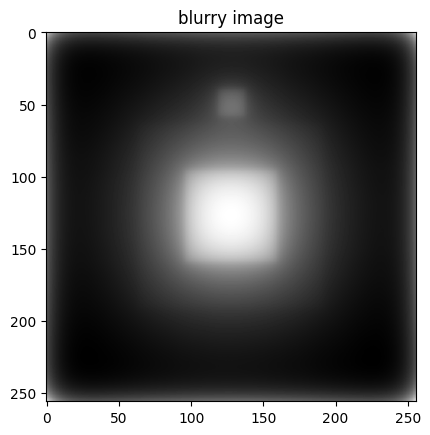

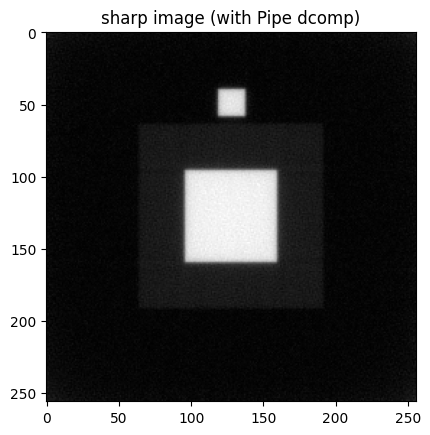

In [16]:
radial_sampling.visual_blurry_sharp_image(kdata_t_myelin, ktraj_total)

#### b. White Matter

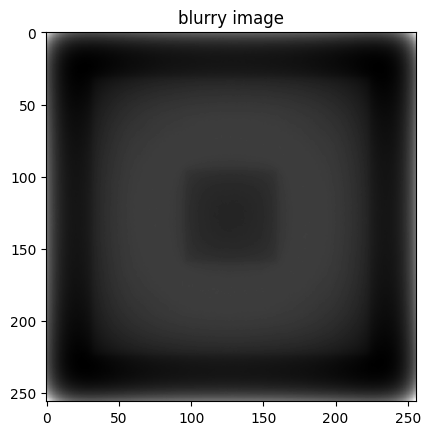

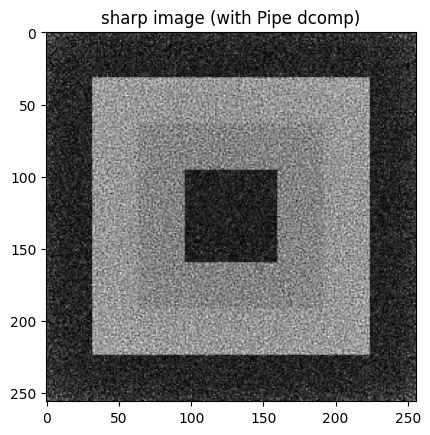

In [17]:
radial_sampling.visual_blurry_sharp_image(kdata_t_wm, ktraj_total)

### 4. Two signals combined

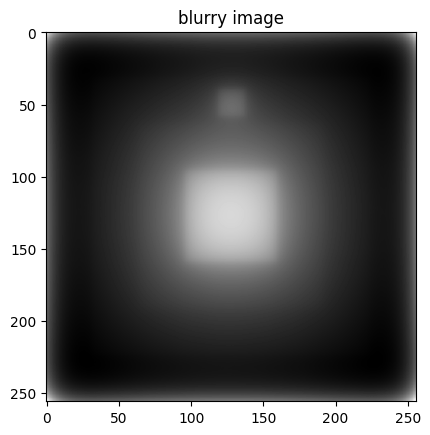

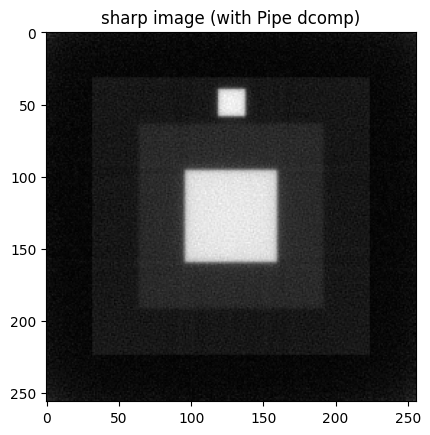

In [18]:
kdata_total = kdata_t_myelin + kdata_t_wm
radial_sampling.visual_blurry_sharp_image(kdata_total, ktraj_total)